# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**:Jerry Lu

**ID**:jl3498

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [52]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\shini\hw3-jerry-hw3`


In [53]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO: 5.67 mg/L at distance x = 24.2 km


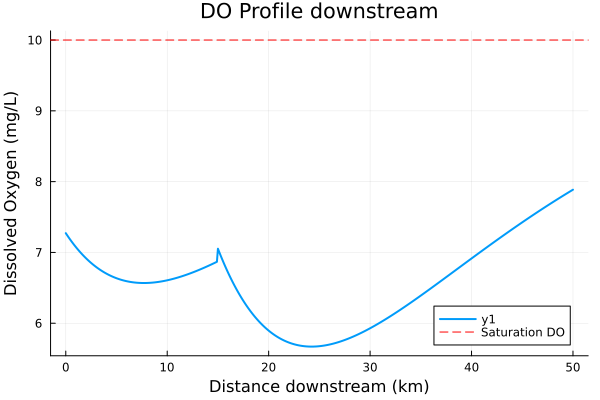

In [54]:
#parameters
Q_river=100000      # m3/day
Q_w1=10000          # m3/day
Q_w2=15000          # m3/day
DO_river=7.5        # mg/L
DO_w1=5             # mg/L
DO_w2=5             # mg/L
CBOD_river=5        # mg/L
CBOD_w1 =50         # mg/L
CBOD_w2 =45         # mg/L
NBOD_river=5        # mg/L
NBOD_w1=35          # mg/L
NBOD_w2=35          # mg/L
k_r=0.55            # reaeration rate 1/d
k_d=0.35            # CBOD decay rate 1/d
k_n=0.25            # NBOD decay rate 1/d
DO_sat=10.0         # saturated DO mg/L

v=6.0               # river velocity km/d
L_w2=15.0           # distance between discharges km

# First discharge mixing
function mix(Q1, C1, Q2, C2)
    return (Q1*C1 + Q2*C2)/(Q1 + Q2)
end

Q_total1=Q_river + Q_w1
DO_mix1=mix(Q_river, DO_river, Q_w1, DO_w1)
CBOD_mix1=mix(Q_river, CBOD_river, Q_w1, CBOD_w1)
NBOD_mix1=mix(Q_river, NBOD_river, Q_w1, NBOD_w1)   

# Second discharge mixing
function second_discharge(Q_total1, DO_mix1, CBOD_mix1, NBOD_mix1, Q_w2, DO_w2, CBOD_w2, NBOD_w2)
    Q_total2=Q_total1 + Q_w2
    DO_mix2=mix(Q_total1, DO_mix1, Q_w2, DO_w2)
    CBOD_mix2=mix(Q_total1, CBOD_mix1, Q_w2, CBOD_w2)
    NBOD_mix2=mix(Q_total1, NBOD_mix1, Q_w2, NBOD_w2)   
    return Q_total2, DO_mix2, CBOD_mix2, NBOD_mix2
end

#Analytical model
function integrate_L(t, CBOD0, k_d, NBOD0, k_n)
    # Analytical solution:
    term_CBOD=CBOD0*k_d/(k_r - k_d)*(exp(-k_d*t)-exp(-k_r*t))
    term_NBOD=NBOD0*k_n/(k_r - k_n)*(exp(-k_n*t)-exp(-k_r*t))
    return term_CBOD + term_NBOD
end

# Streeter–Phelps Equation
function DO_SP(x, DO0, CBOD0, NBOD0, k_r, k_d, k_n, DO_sat, v)
    t = x / v
    # CBOD and NBOD decay
    L=CBOD0*exp(-k_d*t)+NBOD0*exp(-k_n*t)
    D=DO_sat-(DO_sat-DO0)*exp(-k_r*t)-k_r*integrate_L(t, CBOD0, k_d, NBOD0, k_n)
    return D
end

# Downstream DO Simulation
x_vals=0:0.1:50  # distance [km]
DO_vals=Float64[]
for x in x_vals
    if x<L_w2
        push!(DO_vals, DO_SP(x, DO1, CBOD1, NBOD1, k_r, k_d, k_n, DO_sat))
    else
        Q_total2, DO2, CBOD2, NBOD2 = after_second_discharge(Q1_tot, DO1, CBOD1, NBOD1)
        push!(DO_vals, DO_SP(x-L_w2, DO2, CBOD2, NBOD2, k_r, k_d, k_n, DO_sat))
    end
end

# Find minimum DO and its location
DO_min=minimum(DO_vals)
x_min = x_vals[argmin(DO_vals)]

println("Minimum DO: ", round(DO_min, digits=2), " mg/L at distance x = ", round(x_min, digits=2), " km")

# Plotting
plot(x_vals, DO_vals, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="DO Profile downstream", lw=2)
hline!([DO_sat], linestyle=:dash, color=:red, label="Saturation DO")

The mixing function finds the concentration after mixing two flows with c1 and c2 and d1 and d2. After the first discharge, new initial values for Q_total1, DO_mix1, CBOD_mix1, NBOD_mix1 were found using the mix function. Function second_discharge finds the new initial values for the flow and concentrations for after the second wastewater inflow joins the river. The function DO_SP computes the Streeter–Phelps Equation and the function integrate_L is the analytical soultion of oxygen consumption and recovery process over time t. The Downstream DO Simulation finds the DO by using conditions after each discharge every .1 km which is then computed with its location.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Analytical: DOmin=5.572 mg/L at 24.5 km
Numerical:   DOmin=3.637 mg/L at 22.0 km


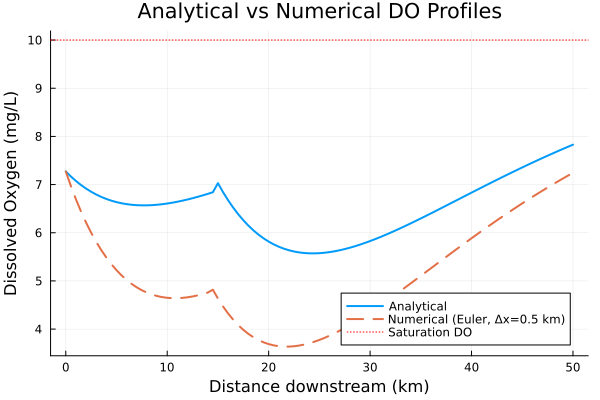

In [65]:
# Parameters
Q_river=100000      # m3/day
Q_w1=10000          # m3/day
Q_w2=15000          # m3/day
DO_river=7.5        # mg/L
DO_w1=5.0           # mg/L
DO_w2=5.0           # mg/L
CBOD_river=5.0      # mg/L
CBOD_w1=50.0        # mg/L
CBOD_w2=45.0        # mg/L
NBOD_river=5.0      # mg/L
NBOD_w1=35.0        # mg/L
NBOD_w2=35.0        # mg/L
k_r=0.55            # reaeration rate [1/d]
k_d=0.35            # CBOD decay rate [1/d]
k_n=0.25            # NBOD decay rate [1/d]
DO_sat=10.0         # saturated DO [mg/L]
v=6.0               # river velocity [km/d]
L_w2=15.0           # distance between discharges [km]


# Mixing functions
function mix(Q1, C1, Q2, C2)
    return (Q1*C1+Q2*C2)/(Q1+Q2)
end

# After first discharge
Q_total1=Q_river+Q_w1
DO1=mix(Q_river, DO_river, Q_w1, DO_w1)
CBOD1=mix(Q_river, CBOD_river, Q_w1, CBOD_w1)
NBOD1=mix(Q_river, NBOD_river, Q_w1, NBOD_w1)

# After second discharge
function second_discharge(Q_total1, DO_mix1, CBOD_mix1, NBOD_mix1, Q_w2, DO_w2, CBOD_w2, NBOD_w2)
    Q_total2=Q_total1+Q_w2
    DO_mix2=mix(Q_total1, DO_mix1, Q_w2, DO_w2)
    CBOD_mix2=mix(Q_total1, CBOD_mix1, Q_w2, CBOD_w2)
    NBOD_mix2=mix(Q_total1, NBOD_mix1, Q_w2, NBOD_w2)
    return Q_total2, DO_mix2, CBOD_mix2, NBOD_mix2
end

# Numerical Simulation (Euler)
Δx=0.5                   # spatial step [km]
x_vals=0:Δx:50.0         # distance array [km]
Δt=Δx/v                # time step [days]
nsteps=length(x_vals)
DO_num=zeros(nsteps)
CBOD_num=zeros(nsteps)
NBOD_num=zeros(nsteps)

# Initial conditions after first discharge
DO_num[1]=DO1
CBOD_num[1]=CBOD1
NBOD_num[1]=NBOD1

for i in 2:nsteps
    x=x_vals[i]

    # Apply second discharge when crossing 15 km
    if abs(x-L_w2) < Δx/2
        Q_total1, DO_mix2, CBOD_mix2, NBOD_mix2=second_discharge(Q_total1, DO_num[i-1], CBOD_num[i-1], NBOD_num[i-1], Q_w2, DO_w2, CBOD_w2, NBOD_w2)
        DO_num[i-1]=DO_mix2
        CBOD_num[i-1]=CBOD_mix2
        NBOD_num[i-1]=NBOD_mix2
    end

    # Rate of change (ODEs)
    dCBOD=-k_d*CBOD_num[i-1]
    dNBOD=-k_n*NBOD_num[i-1]
    dDO=k_r*(DO_sat-DO_num[i-1])-k_d*CBOD_num[i-1]-k_n*NBOD_num[i-1]

    # Euler update
    CBOD_num[i]=CBOD_num[i-1]+dCBOD*Δt
    NBOD_num[i]=NBOD_num[i-1]+dNBOD*Δt
    DO_num[i]=DO_num[i-1]+dDO*Δt
end


# Analytical solution functions
function integrate_L(t, CBOD0, k_d, NBOD0, k_n, k_r)
    term_CBOD=CBOD0*k_d/(k_r-k_d)*(exp(-k_d*t)-exp(-k_r*t))
    term_NBOD=NBOD0*k_n/(k_r-k_n)*(exp(-k_n*t)-exp(-k_r*t))
    return term_CBOD+term_NBOD
end

function DO_SP(x, DO0, CBOD0, NBOD0, k_r, k_d, k_n, DO_sat, v)
    t=x/v
    D=DO_sat-(DO_sat-DO0)*exp(-k_r*t)-k_r*integrate_L(t, CBOD0, k_d, NBOD0, k_n, k_r)
    return D
end

# After second discharge (analytical)
Q2_tot, DO2, CBOD2, NBOD2=second_discharge(Q_total1, DO1, CBOD1, NBOD1, Q_w2, DO_w2, CBOD_w2, NBOD_w2)

# Analytical profile
DO_ana=[x < L_w2 ? DO_SP(x, DO1, CBOD1, NBOD1, k_r, k_d, k_n, DO_sat, v) : 
    DO_SP(x-L_w2, DO2, CBOD2, NBOD2, k_r, k_d, k_n, DO_sat, v)
    for x in x_vals]


# Minimum DO values
DO_min_num=minimum(DO_num)
x_min_num=x_vals[argmin(DO_num)]

DO_min_ana=minimum(DO_ana)
x_min_ana=x_vals[argmin(DO_ana)]

println("Analytical: DOmin=$(round(DO_min_ana, digits=3)) mg/L at $(x_min_ana) km")
println("Numerical:   DOmin=$(round(DO_min_num, digits=3)) mg/L at $(x_min_num) km")


# Plot results
plot(x_vals, DO_ana, label="Analytical", lw=2)
plot!(x_vals, DO_num, label="Numerical (Euler, Δx=0.5 km)", lw=2, linestyle=:dash)
hline!([DO_sat], linestyle=:dot, color=:red, label="Saturation DO")
xlabel!("Distance downstream (km)")
ylabel!("Dissolved Oxygen (mg/L)")
title!("Analytical vs Numerical DO Profiles")


The min value for the numerical decreased compared to the analytical solution. The numerical solution could have discretization error as it approximates the rate of change over each .5km while the DO actually changes nonlinearly. The CBOD, NBOD, and DO are also assumed to be constant during each time step which can cause differences in oxygen consumption and reaeration recovery.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

With a 5% margin of safety, the dissolved oxygen concentration becomes 4 mg/L×1.05=4.2 mg/L. Since the analytical model shows that the DOmin=5.572 mg/L at 24.5 km, neither waste streams need to be treated as the min is already above the standard.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

I would treat stream 2 alone first since it would remove more BOD mass per % and it is closer to the DO critical point meaning more DO benefits for the same treatment. If the budget is sufficient, I would like to treat both streams. Other information I would need would be the general costs, any contraints like discharge limits, and the location availability for treatment.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [ ]:
# Monte Carlo Simulation
n=10000 
DO_inflow_dist=LogNormal(2.0, 0.15)
DO_inflow_samples=rand(DO_inflow_dist, n)
DOmin_samples=zeros(n)

# Monte Carlo loop
for i in 1:n
    DO0=DO_inflow_samples[i]
    # Compute post-treatment mixing at first discharge
    DO1=mix(Q_river, DO_river, Q_w1, DO_w1)
    CBOD1=mix(Q_river, CBOD_river, Q_w1, CBOD_w1)
    NBOD1=mix(Q_river, NBOD_river, Q_w1, NBOD_w1)
    # Compute DO along river (0–50 km)
    DO_profile=[x<L_w2 ? DO_SP(x, DO1, CBOD1, NBOD1, k_r, k_d, k_n, DO_sat, v) :
    DO_SP(x-L_w2, DO2, CBOD2, NBOD2, k_r, k_d, k_n, DO_sat, v)
    for x in x_vals ]
    DOmin_samples[i]=minimum(DO_profile)
end

# Statistical analysis
failures=sum(DOmin_samples .< 4)
p_fail=failures/n
SE=sqrt(p_fail*(1-p_fail)/n)
CI_lower=max(0, p_fail-1.96*SE)
CI_upper=min(1, p_fail + 1.96*SE)



0.0

I used n=10000 since $SE = \sqrt{\frac{p(1-p)}{n}}, n=\frac{p(1-p)}{SE^2} =\frac{.5^2}{.01^2}=2500$. Since p=.5 and SE=.01, this means 10000 is enough of a sample to find the probability.

## References

List any external references consulted, including classmates.